# Analyse: min_objective_improvement

Deze notebook analyseert de resultaten uit `Fase1_Analysis_aangepast_versie2 copy.ipynb`  
en vergelijkt **per trigger-configuratie** de effecten van verschillende waarden van `min_objective_improvement`.

## Experimentopzet

| Parameter | Waarden |
|---|---|
| `min_objective_improvement` (MOI) | Geen drempel (−10 000), 60 s, 120 s, 180 s, 300 s |
| Trigger-strategie | `periodic` (prf=900), `periodic` (prf=3600), `event_driven` (edf=900, cf=450), `event_driven` (edf=3600, cf=900) |
| Referentie | **Baseline** (FCFS only — solver vuurt nooit) |
| Seeds per config | 50 |

**Wat doet MOI?**  
De solver accepteert een nieuw rooster enkel als de verbetering groter is dan `min_objective_improvement` (in seconden).  
- **Geen drempel** (MOI = −10 000): elke verbetering wordt geaccepteerd — meest agressief.  
- **MOI = 300**: solver vuurt alleen bij ≥ 5 min winst — meest conservatief.  
- **Baseline**: FCFS, solver vuurt nooit. Dient als ondergrens voor vergelijking.

## Vragen die we beantwoorden

1. Hoe beïnvloedt MOI de **vertraging** (TED_combined, TED_passenger, TED_freight)?
2. Hoe beïnvloedt MOI de **solver-inspanning** (n_rescheduled, total_solve_time)?
3. Wat is de **Pareto-trade-off** tussen vertraging en inspanning t.o.v. de baseline?
4. Zijn de verschillen **statistisch significant**?

## 1. Setup

In [1]:
import sys
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

# ── Paden ──────────────────────────────────────────────────────────────────
RESULTS_DIR = Path.cwd().parent / "results" / "Min_objective_improvement_goedeversie!!"

# ── MOI-waarden (gesorteerd van meest naar minst agressief) ────────────────
# -10000 = "geen drempel" — elke verbetering wordt geaccepteerd
MOI_VALUES  = [-10000, 60, 120, 180, 300]

MOI_LABELS  = {          # voor x-assen en titels
    -10000: "Geen\ndrempel",
    60:     "60",
    120:    "120",
    180:    "180",
    300:    "300",
}
MOI_LABELS_SHORT = {     # voor legendas en annotaties
    -10000: "Geen drempel",
    60:     "60s",
    120:    "120s",
    180:    "180s",
    300:    "300s",
}
MOI_COLORS  = {
    -10000: "#9467bd",   # paars  — geen drempel
    60:     "#1f77b4",   # blauw
    120:    "#ff7f0e",   # oranje
    180:    "#2ca02c",   # groen
    300:    "#d62728",   # rood
}

TRIGGER_LABELS = {
    "periodic_prf900":   "Periodic (prf=900s)",
    "periodic_prf3600":  "Periodic (prf=3600s)",
    "ed_edf900":         "Event-Driven (edf=900s, cf=450s)",
    "ed_edf3600":        "Event-Driven (edf=3600s, cf=900s)",
}

marker_per_trigger = {
    "periodic_prf900":  "o",
    "periodic_prf3600": "s",
    "ed_edf900":        "^",
    "ed_edf3600":       "D",
}
color_per_trigger = {
    "periodic_prf900":  "#1f77b4",
    "periodic_prf3600": "#ff7f0e",
    "ed_edf900":        "#2ca02c",
    "ed_edf3600":       "#d62728",
}
BASELINE_COLOR = "#7f7f7f"   # grijs — voor referentielijnen

# ── Plotstijl ──────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

print(f"Results dir: {RESULTS_DIR.resolve()}")
print(f"Bestaat: {RESULTS_DIR.exists()}")

Results dir: /Users/ddw/Desktop/Rescheduling/results/Min_objective_improvement_goedeversie!!
Bestaat: True


## 2. Data laden

In [2]:
def load_all_raw(results_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Laadt alle raw_runs.csv bestanden.

    Geeft drie DataFrames terug:
      df               : voltooide niet-baseline runs (deadlocks uitgesloten)
      df_baseline      : baseline runs (deadlocks uitgesloten)
      deadlock_summary : n_total / n_deadlock / deadlock_pct per (trigger_key × moi)
                         inclusief baseline, inclusief deadlock-runs
    """
    frames = []
    for csv_path in sorted(results_dir.rglob("raw_runs.csv")):
        df_tmp = pd.read_csv(csv_path)
        df_tmp["config_dir"] = csv_path.parent.name
        frames.append(df_tmp)

    if not frames:
        raise FileNotFoundError(f"Geen raw_runs.csv gevonden in {results_dir}")

    raw = pd.concat(frames, ignore_index=True)
    raw["moi"] = raw["min_objective_improvement"].astype(int)

    def _trigger_key(row):
        ts  = row["strategy_type"]
        prf = int(row["periodic_rf"]) if pd.notna(row["periodic_rf"]) else None
        if ts == "periodic" and prf == 100_000:
            return "baseline"
        elif ts == "periodic":
            return f"periodic_prf{prf}"
        elif ts == "event_driven":
            return f"ed_edf{int(row['event_driven_rf'])}"
        return ts

    raw["trigger_key"] = raw.apply(_trigger_key, axis=1)

    # ── Deadlock-samenvatting (vóór filteren) ────────────────────────────
    dl_col = raw["deadlock"].fillna(False).astype(bool)
    deadlock_summary = (
        raw.groupby(["trigger_key", "moi"])
           .agg(n_total=("seed", "count"), n_deadlock=(dl_col.name, "sum"))
           .reset_index()
    )
    deadlock_summary["deadlock_pct"] = (
        deadlock_summary["n_deadlock"] / deadlock_summary["n_total"] * 100
    ).round(1)
    deadlock_summary["moi_label"] = deadlock_summary["moi"].map(MOI_LABELS_SHORT).fillna(
        deadlock_summary["moi"].astype(str)
    )

    # ── Deadlocks verwijderen voor verdere analyse ────────────────────────
    n_total    = len(raw)
    n_deadlock = int(dl_col.sum())
    clean      = raw[~dl_col].copy()

    df_baseline = clean[clean["trigger_key"] == "baseline"].copy()
    df          = clean[clean["trigger_key"] != "baseline"].copy()

    # ── Rapportage ────────────────────────────────────────────────────────
    print(f"Totaal geladen:   {n_total} rijen")
    print(f"Deadlocks:        {n_deadlock} rijen uitgesloten  "
          f"({n_deadlock/n_total*100:.1f}%)")
    print(f"Baseline seeds:   {len(df_baseline)}")
    print(f"Overige seeds:    {len(df)}")
    print()

    counts = df.groupby(["trigger_key", "moi"]).size().reset_index(name="n_seeds")
    counts["moi_label"] = counts["moi"].map(MOI_LABELS_SHORT).fillna(counts["moi"].astype(str))
    print("Seeds per (trigger × MOI) na deadlock-filter:")
    print(counts.to_string(index=False))

    return df, df_baseline, deadlock_summary


df, df_baseline, deadlock_summary = load_all_raw(RESULTS_DIR)

Totaal geladen:   1050 rijen
Deadlocks:        17 rijen uitgesloten  (1.6%)
Baseline seeds:   49
Overige seeds:    984

Seeds per (trigger × MOI) na deadlock-filter:
     trigger_key    moi  n_seeds    moi_label
      ed_edf3600 -10000       50 Geen drempel
      ed_edf3600     60       50          60s
      ed_edf3600    120       50         120s
      ed_edf3600    180       50         180s
      ed_edf3600    300       50         300s
       ed_edf900 -10000       48 Geen drempel
       ed_edf900     60       50          60s
       ed_edf900    120       48         120s
       ed_edf900    180       49         180s
       ed_edf900    300       50         300s
periodic_prf3600 -10000       49 Geen drempel
periodic_prf3600     60       50          60s
periodic_prf3600    120       50         120s
periodic_prf3600    180       48         180s
periodic_prf3600    300       48         300s
 periodic_prf900 -10000       50 Geen drempel
 periodic_prf900     60       47          60s
 perio

In [3]:
# ── Datakwaliteit ────────────────────────────────────────────────────────────
seed_counts = df.groupby(["trigger_key", "moi"]).size().reset_index(name="n_seeds")
incomplete  = seed_counts[seed_counts["n_seeds"] < 10]
if not incomplete.empty:
    print("⚠️  Configs met weinig seeds (mogelijk nog aan het runnen):")
    for _, row in incomplete.iterrows():
        lbl = MOI_LABELS_SHORT.get(row["moi"], str(row["moi"]))
        print(f"   {row['trigger_key']} | MOI={lbl} → {row['n_seeds']} seeds")
    print()
else:
    print("✓ Alle configs hebben ≥ 10 seeds.")
    print()

print(f"Baseline: {len(df_baseline)} seeds  "
      f"(gem. TED_combined = {df_baseline['TED_combined'].mean():.0f} s)")
print()

# ── Gemiddelden per config-groep ─────────────────────────────────────────────
METRICS = [
    "TED_combined", "TED_passenger", "TED_freight",
    "delay_ratio",
    "n_rescheduled", "n_skipped", "total_solve_time",
]

trigger_keys = sorted(df["trigger_key"].unique())
n_triggers   = len(trigger_keys)

agg = (
    df.groupby(["trigger_key", "moi"])[METRICS]
      .agg(["mean", "std", "median"])
      .round(1)
)

# Beschikbare MOI-waarden in de data (kan minder zijn dan MOI_VALUES)
MOI_PRESENT = sorted(df["moi"].unique())

print("Aanwezige MOI-waarden in data:", [MOI_LABELS_SHORT.get(m, m) for m in MOI_PRESENT])
print()
print("Geaggregeerde statistieken per trigger × MOI (TED_combined + inspanning):")
agg[["TED_combined", "n_rescheduled"]]

✓ Alle configs hebben ≥ 10 seeds.

Baseline: 49 seeds  (gem. TED_combined = 46935 s)

Aanwezige MOI-waarden in data: ['Geen drempel', '60s', '120s', '180s', '300s']

Geaggregeerde statistieken per trigger × MOI (TED_combined + inspanning):


TED_combined                  n_rescheduled       \
                                mean     std   median          mean  std   
trigger_key      moi                                                       
ed_edf3600       -10000      46955.8  3474.3  46507.3          19.3  1.0   
                  60         46621.0  3453.4  46344.4          12.8  1.9   
                  120        46753.0  3282.6  46252.1           9.3  1.2   
                  180        47177.1  3297.0  46829.1           7.6  1.4   
                  300        47549.4  3331.8  46956.8           5.0  1.1   
ed_edf900        -10000      48789.8  4741.7  47279.2          64.6  2.7   
                  60         47320.7  3438.4  47113.7          33.5  3.8   
                  120        47285.5  3815.4  46659.8          22.4  2.8   
                  180        46880.9  3835.8  46648.9          16.9  2.5   
                  300        47242.8  3801.0  46689.3          10.0  2.0   
periodic_prf3600 -10000      47079.1  3457.8  46470.4          23.6  0.5   
                  60         46933.5  3837.6  46433.6          15.0  1.1   
                  120        46699.8  3601.4  46394.2          10.6  1.1   
                  180        46966.8  3555.4  46292.9           8.9  1.2   
                  300        47226.7  3618.7  46386.2           5.0  1.0   
periodic_prf900  -10000      48980.8  5382.4  48468.3          93.9  0.5   
                  60         47692.4  4264.5  46526.4          41.4  3.4   
                  120        46851.6  3443.1  46800.9          26.6  3.7   
                  180        47118.4  3352.6  46413.4          18.3  3.2   
                  300        46873.2  3352.2  46701.6          10.9  2.2   

                                
                        median  
trigger_key      moi            
ed_edf3600       -10000   19.0  
                  60      13.0  
                  120      9.0  
                  180      8.0  
                  300      5.0  
ed_edf900        -10000   64.0  
                  60      34.0  
                  120     23.0  
                  180     17.0  
                  300     10.0  
periodic_prf3600 -10000   24.0  
                  60      15.0  
                  120     11.0  
                  180      9.0  
                  300      5.0  
periodic_prf900  -10000   94.0  
                  60      42.0  
                  120     27.0  
                  180     18.0  
                  300     11.0

## 2.1 Deadlock-analyse

Een **deadlock** treedt op wanneer de simulator vastloopt in een circulaire blokkering.
Die run wordt volledig uitgesloten van alle performantie- en inspanningsanalyses.

Hier bekijken we:
- **Hoeveel** deadlocks per (trigger × MOI)
- Of de deadlock-rate **systematisch varieert** met MOI (hogere drempel = meer/minder deadlocks?)
- Of bepaalde trigger-configuraties **structureel gevoeliger** zijn

> **Interpretatie-kanttekening:** met 50 seeds per config zijn de aantallen klein.
> Een verschil van 1–2 deadlocks representeert slechts 2–4 % en is statistisch weinig robuust.
> Focus op het patroon over meerdere configs, niet op individuele cellen.

In [4]:
# ── Overzichtstabel deadlocks ────────────────────────────────────────────────
dl_pivot = deadlock_summary.copy()
dl_pivot["label"] = dl_pivot["n_deadlock"].astype(str) + "  (" + dl_pivot["deadlock_pct"].astype(str) + "%)"

n_total_all = deadlock_summary["n_total"].sum()
n_dl_all    = deadlock_summary["n_deadlock"].sum()
print(f"Totaal: {n_dl_all} deadlocks op {n_total_all} runs  "
      f"({n_dl_all/n_total_all*100:.1f}%)\n")

# Tabel gesorteerd op deadlock_pct
display(
    deadlock_summary[deadlock_summary["n_deadlock"] > 0]
    .sort_values("deadlock_pct", ascending=False)
    [["trigger_key", "moi_label", "n_total", "n_deadlock", "deadlock_pct"]]
    .rename(columns={
        "trigger_key":   "Trigger",
        "moi_label":     "MOI",
        "n_total":       "n runs",
        "n_deadlock":    "n deadlocks",
        "deadlock_pct":  "deadlock %",
    })
    .reset_index(drop=True)
    .style.background_gradient(subset=["deadlock %"], cmap="Reds", vmin=0, vmax=10)
          .format({"deadlock %": "{:.1f}%"})
)

Totaal: 17 deadlocks op 1050 runs  (1.6%)



,Trigger,MOI,n runs,n deadlocks,deadlock %
0,periodic_prf900,60s,50,3,6.0%
1,ed_edf900,Geen drempel,50,2,4.0%
2,ed_edf900,120s,50,2,4.0%
3,periodic_prf3600,180s,50,2,4.0%
4,periodic_prf3600,300s,50,2,4.0%
5,periodic_prf900,120s,50,2,4.0%
6,baseline,0,50,1,2.0%
7,ed_edf900,180s,50,1,2.0%
8,periodic_prf3600,Geen drempel,50,1,2.0%
9,periodic_prf900,180s,50,1,2.0%


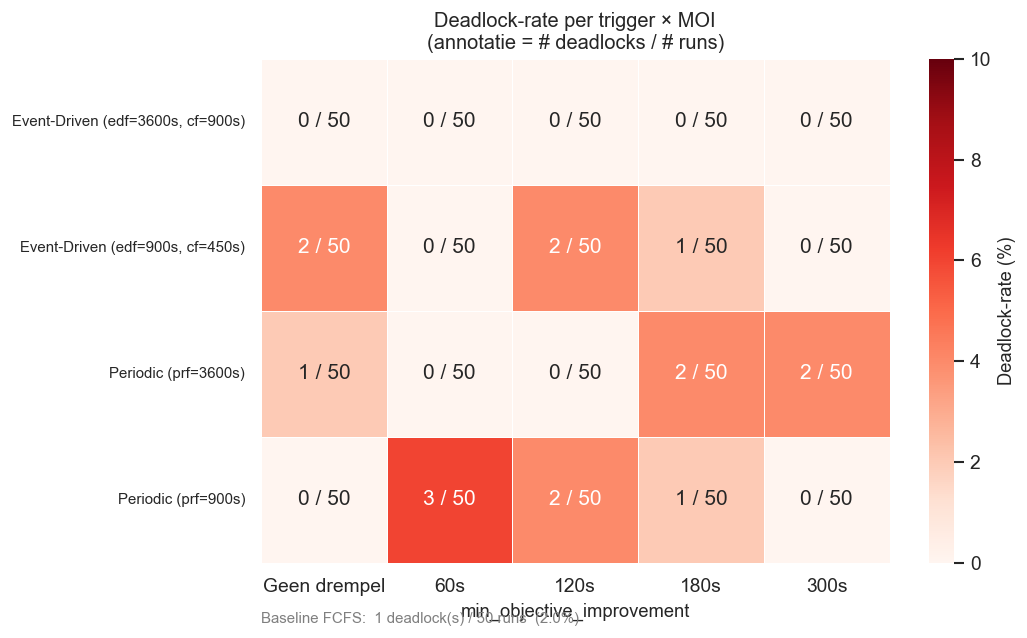

In [5]:
# ── Heatmap: deadlock-rate per (trigger × MOI) ───────────────────────────────
# Alleen niet-baseline configs
dl_regulier = deadlock_summary[deadlock_summary["trigger_key"] != "baseline"].copy()
dl_baseline = deadlock_summary[deadlock_summary["trigger_key"] == "baseline"].copy()

# Pivot: rijen = trigger_key, kolommen = moi_label (gesorteerd op MOI_PRESENT)
moi_order  = [MOI_LABELS_SHORT.get(m, str(m)) for m in sorted(dl_regulier["moi"].unique())]
tkey_order = sorted(dl_regulier["trigger_key"].unique())

pivot = dl_regulier.pivot_table(
    index="trigger_key",
    columns="moi_label",
    values="deadlock_pct",
    aggfunc="first",
).reindex(index=tkey_order, columns=moi_order)

# Annotaties: "n / N" formaat
annot = dl_regulier.pivot_table(
    index="trigger_key",
    columns="moi_label",
    values="n_deadlock",
    aggfunc="first",
).reindex(index=tkey_order, columns=moi_order)

n_tot = dl_regulier.pivot_table(
    index="trigger_key",
    columns="moi_label",
    values="n_total",
    aggfunc="first",
).reindex(index=tkey_order, columns=moi_order)

annot_str = annot.astype(int).astype(str) + " / " + n_tot.astype(int).astype(str)

fig, ax = plt.subplots(figsize=(len(moi_order) * 1.6 + 1, len(tkey_order) * 1.0 + 1.5))

sns.heatmap(
    pivot,
    ax=ax,
    annot=annot_str,
    fmt="",
    cmap="Reds",
    vmin=0, vmax=10,
    linewidths=0.5,
    cbar_kws={"label": "Deadlock-rate (%)"},
)

ax.set_yticklabels(
    [TRIGGER_LABELS.get(k, k) for k in tkey_order],
    rotation=0, fontsize=9,
)
ax.set_xlabel("min_objective_improvement")
ax.set_ylabel("")
ax.set_title("Deadlock-rate per trigger × MOI\n(annotatie = # deadlocks / # runs)")

# Voeg baseline toe als tekst onder de plot
if not dl_baseline.empty:
    bl_row = dl_baseline.iloc[0]
    ax.text(
        0.0, -0.12,
        f"Baseline FCFS:  {int(bl_row['n_deadlock'])} deadlock(s) / "
        f"{int(bl_row['n_total'])} runs  ({bl_row['deadlock_pct']:.1f}%)",
        transform=ax.transAxes,
        fontsize=9, color=BASELINE_COLOR,
    )

plt.tight_layout()
plt.show()

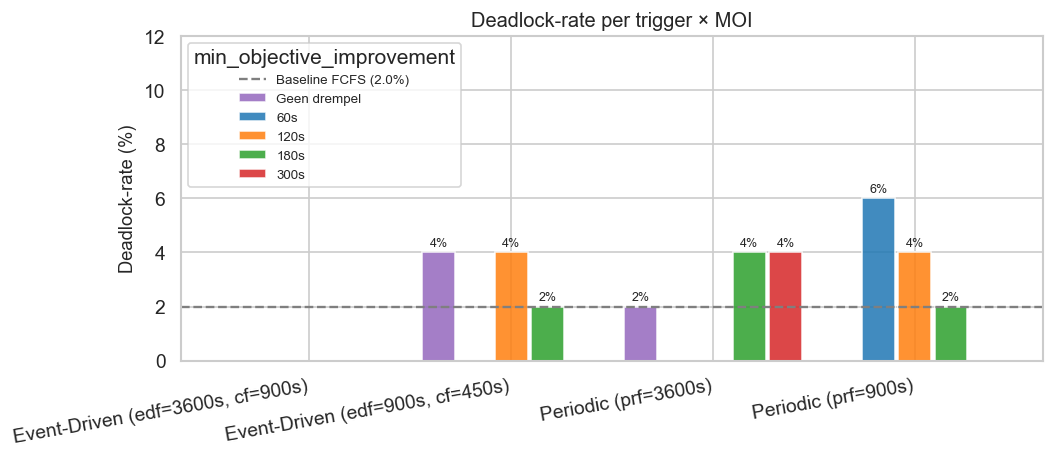

In [6]:
# ── Barplot: deadlock-rate per MOI, per trigger ───────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

width  = 0.18
x_pos  = np.arange(len(tkey_order))

for i, moi in enumerate(sorted(dl_regulier["moi"].unique())):
    rates = []
    for tkey in tkey_order:
        row = dl_regulier[(dl_regulier["trigger_key"] == tkey) & (dl_regulier["moi"] == moi)]
        rates.append(float(row["deadlock_pct"].iloc[0]) if not row.empty else 0.0)

    bars = ax.bar(
        x_pos + i * width,
        rates,
        width=width * 0.9,
        label=MOI_LABELS_SHORT.get(moi, str(moi)),
        color=MOI_COLORS.get(moi, "#aaaaaa"),
        alpha=0.85,
        edgecolor="white",
    )

    for bar, val in zip(bars, rates):
        if val > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.1,
                f"{val:.0f}%",
                ha="center", va="bottom", fontsize=7.5,
            )

# Baseline als horizontale lijn
if not dl_baseline.empty:
    bl_pct = float(dl_baseline["deadlock_pct"].iloc[0])
    ax.axhline(bl_pct, color=BASELINE_COLOR, linestyle="--", linewidth=1.4,
               label=f"Baseline FCFS ({bl_pct:.1f}%)")

ax.set_xticks(x_pos + width * (len(MOI_PRESENT) - 1) / 2)
ax.set_xticklabels([TRIGGER_LABELS.get(k, k) for k in tkey_order], rotation=10, ha="right")
ax.set_ylabel("Deadlock-rate (%)")
ax.set_title("Deadlock-rate per trigger × MOI")
ax.set_ylim(0, 12)
ax.legend(title="min_objective_improvement", fontsize=8)

plt.tight_layout()
plt.show()

## 3. Performantie: TED per MOI-waarde

Boxplots van `TED_combined`, `TED_passenger` en `TED_freight` per MOI-waarde,  
opgesplitst per trigger-configuratie.

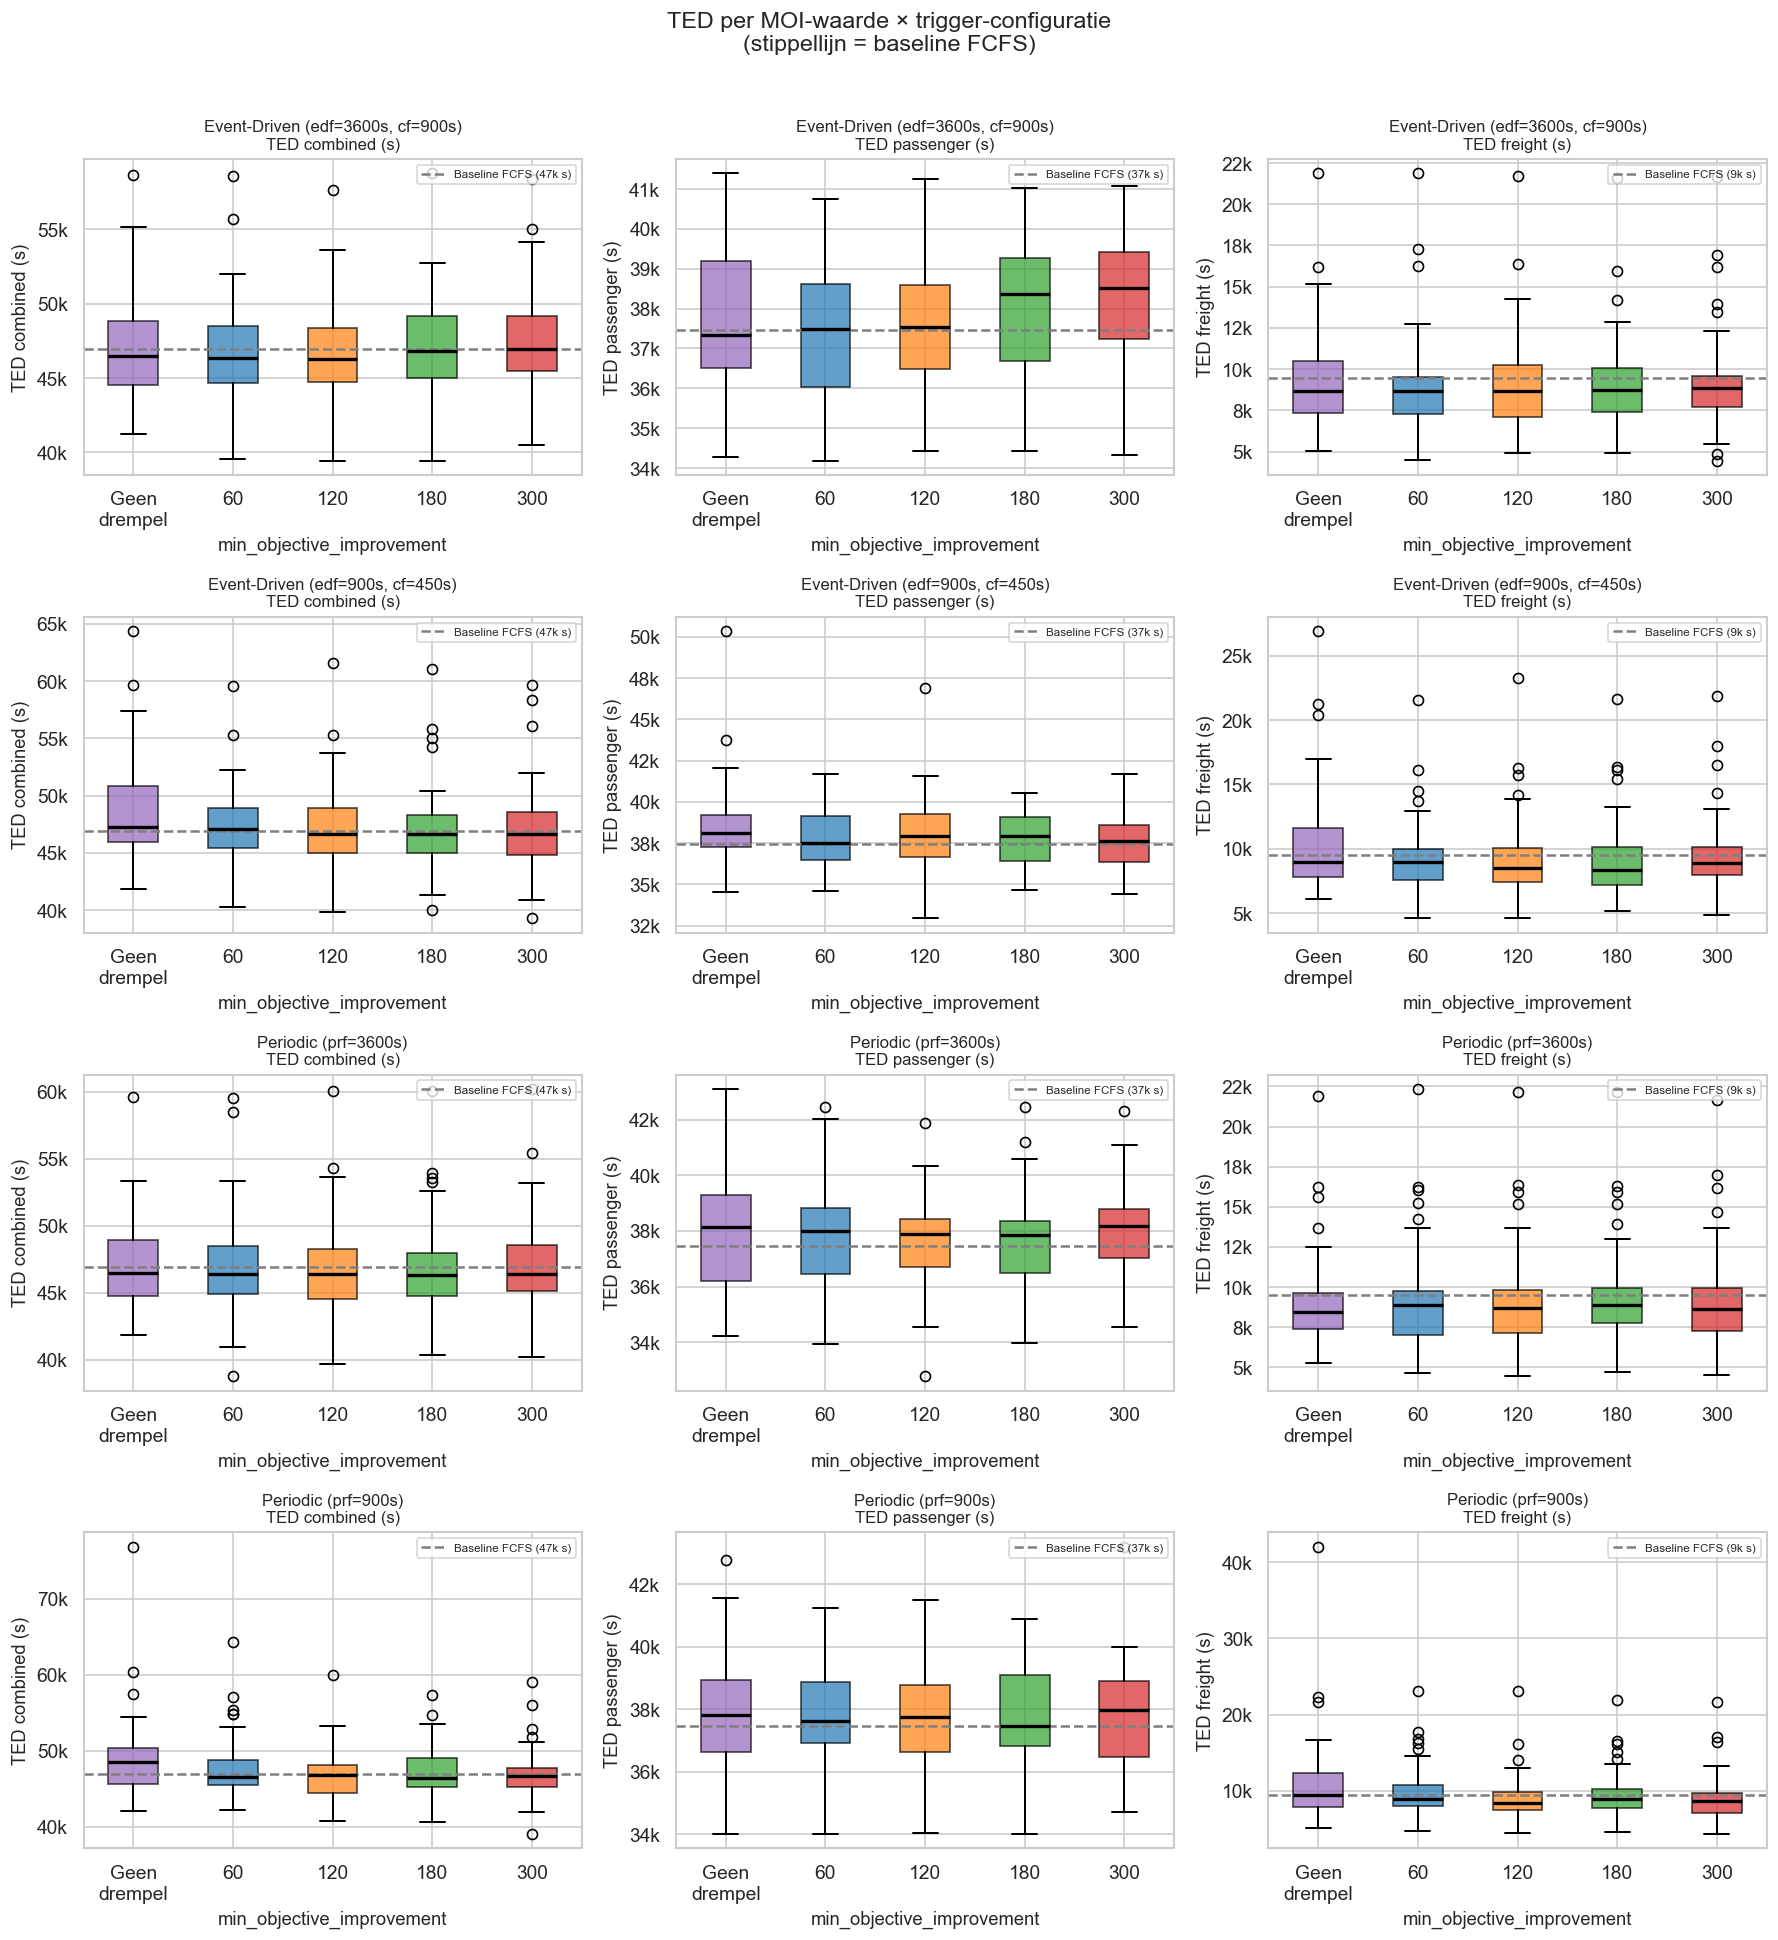

In [7]:
ted_cols   = ["TED_combined", "TED_passenger", "TED_freight"]
ted_labels = ["TED combined (s)", "TED passenger (s)", "TED freight (s)"]

# ── Baseline referentiewaarden ────────────────────────────────────────────
baseline_means = {col: df_baseline[col].mean() for col in ted_cols}

fig, axes = plt.subplots(n_triggers, 3, figsize=(15, 4 * n_triggers), sharey=False)
if n_triggers == 1:
    axes = axes.reshape(1, -1)

x_labels = [MOI_LABELS.get(m, str(m)) for m in MOI_PRESENT]

for row_i, tkey in enumerate(trigger_keys):
    sub = df[df["trigger_key"] == tkey]

    for col_i, (metric, label) in enumerate(zip(ted_cols, ted_labels)):
        ax = axes[row_i][col_i]

        data_per_moi = [sub[sub["moi"] == m][metric].dropna().values for m in MOI_PRESENT]

        bp = ax.boxplot(
            data_per_moi,
            labels=x_labels,
            patch_artist=True,
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
        )

        for patch, m in zip(bp["boxes"], MOI_PRESENT):
            patch.set_facecolor(MOI_COLORS.get(m, "#aaaaaa"))
            patch.set_alpha(0.7)

        # Baseline referentielijn
        ax.axhline(
            baseline_means[metric],
            color=BASELINE_COLOR,
            linestyle="--",
            linewidth=1.5,
            label=f"Baseline FCFS ({baseline_means[metric]/1000:.0f}k s)",
        )
        ax.legend(fontsize=7, loc="upper right")
        ax.set_title(f"{TRIGGER_LABELS.get(tkey, tkey)}\n{label}", fontsize=10)
        ax.set_xlabel("min_objective_improvement")
        ax.set_ylabel(label)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))

plt.suptitle("TED per MOI-waarde × trigger-configuratie\n(stippellijn = baseline FCFS)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 3.1 Gemiddelde TED als functie van MOI (lijnplot)

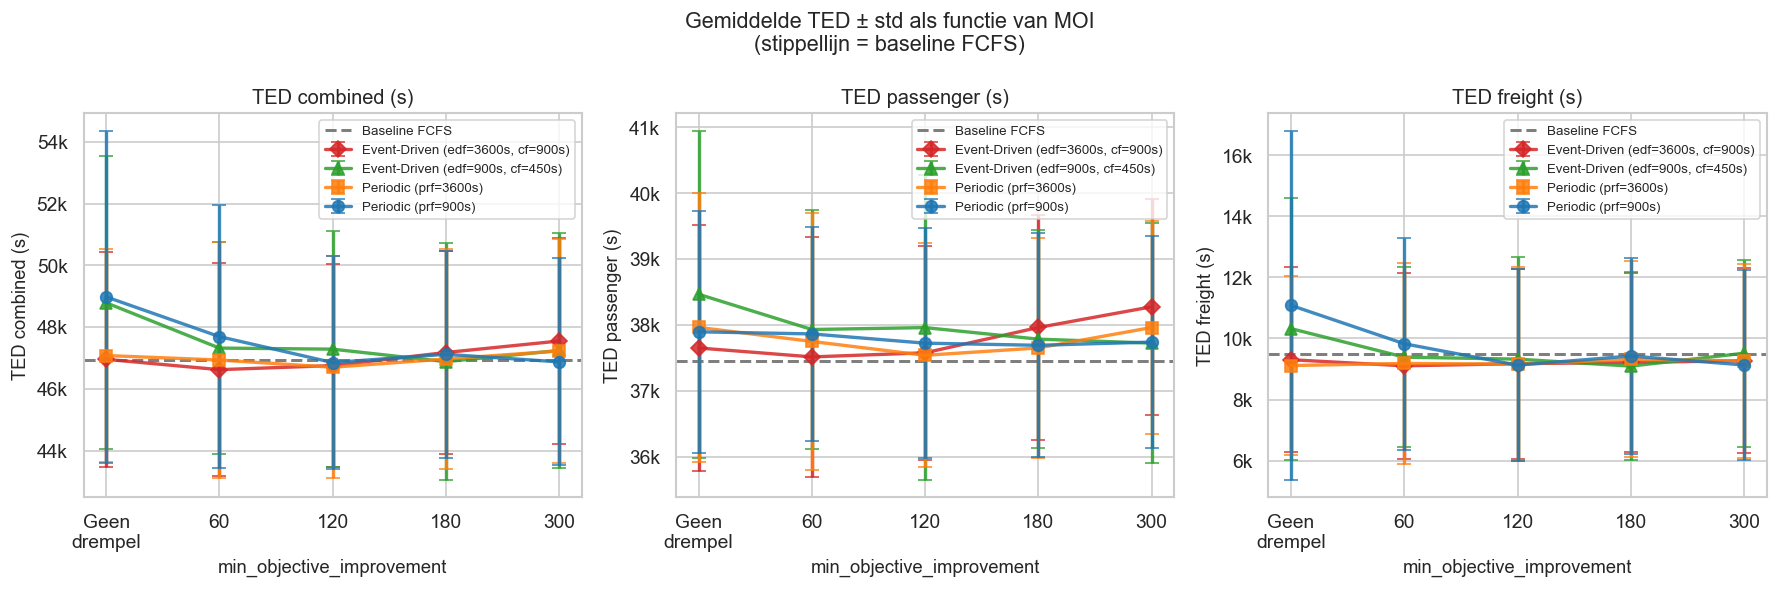

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric, label in zip(
    axes,
    ted_cols,
    ted_labels,
):
    for tkey in trigger_keys:
        sub = df[df["trigger_key"] == tkey]
        grp = sub.groupby("moi")[metric].agg(["mean", "std"]).reindex(MOI_PRESENT)

        ax.errorbar(
            range(len(MOI_PRESENT)),
            grp["mean"],
            yerr=grp["std"],
            label=TRIGGER_LABELS.get(tkey, tkey),
            marker=marker_per_trigger.get(tkey, "o"),
            color=color_per_trigger.get(tkey, "gray"),
            linewidth=2,
            markersize=7,
            capsize=4,
            alpha=0.85,
        )

    # Baseline horizontale referentielijn
    ax.axhline(
        baseline_means[metric],
        color=BASELINE_COLOR,
        linestyle="--",
        linewidth=1.8,
        label="Baseline FCFS",
        zorder=1,
    )

    ax.set_title(label)
    ax.set_xlabel("min_objective_improvement")
    ax.set_xticks(range(len(MOI_PRESENT)))
    ax.set_xticklabels([MOI_LABELS.get(m, str(m)) for m in MOI_PRESENT])
    ax.set_ylabel(label)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
    ax.legend(fontsize=8)

plt.suptitle("Gemiddelde TED ± std als functie van MOI\n(stippellijn = baseline FCFS)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Solver-inspanning: n_rescheduled, n_skipped, total_solve_time

Hogere MOI → solver vuurt minder vaak → minder rekentijd.  
Dit is de verwachte trade-off die we hier kwantificeren.

> **Let op:** `n_skipped` telt **alle** controllerticks waar geen solver-aanroep plaatsvond  
> (ook gewone ticks tussen twee trigger-momenten in). Het wordt dus gedomineerd door de  
> trigger-frequentie en verandert nauwelijks met MOI. **`n_rescheduled`** is de zuivere  
> MOI-indicator: dat daalt duidelijk naarmate MOI toeneemt.

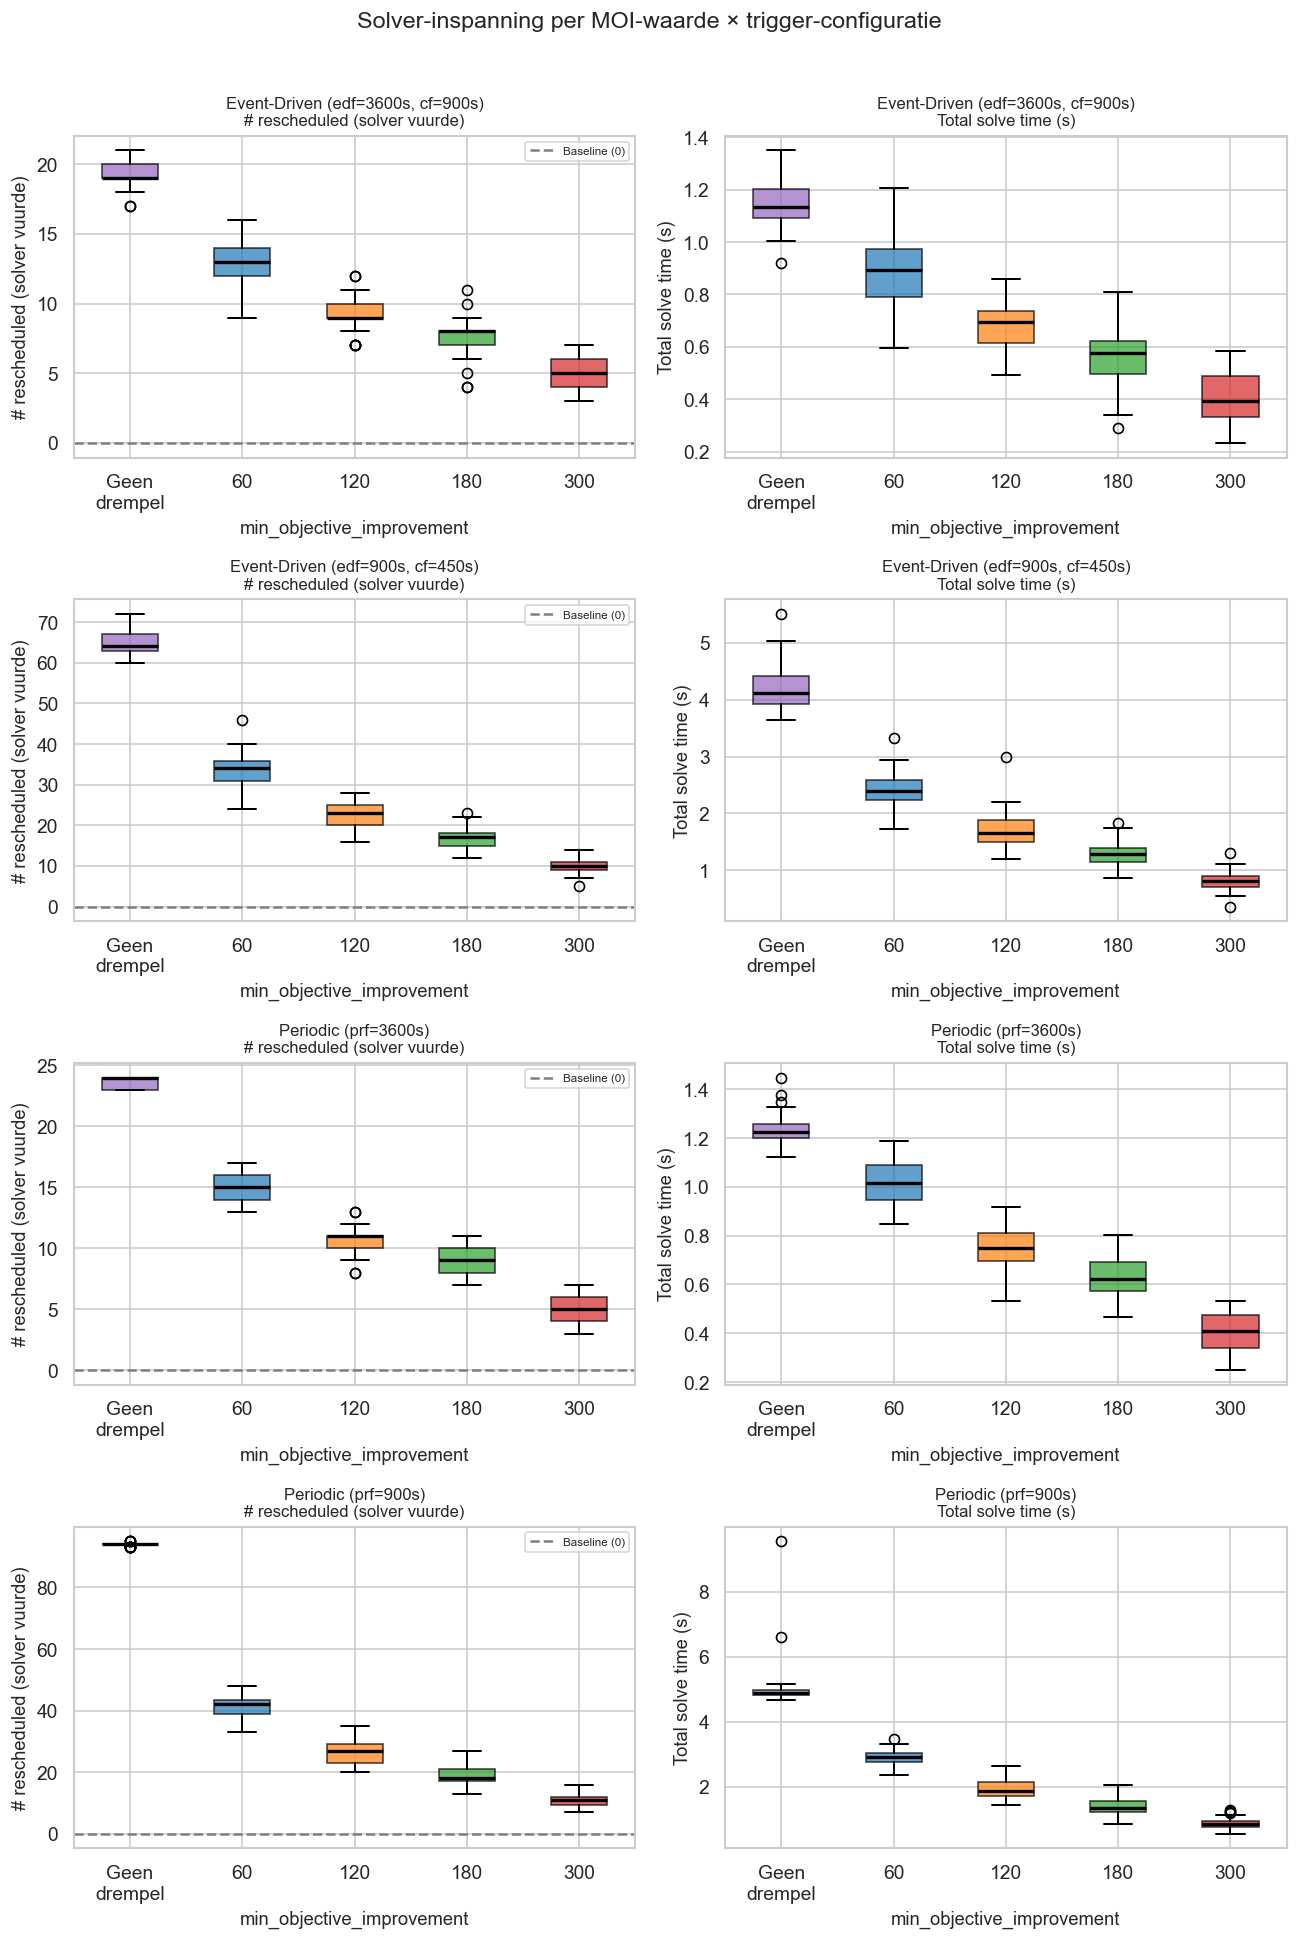

In [9]:
effort_cols   = ["n_rescheduled", "total_solve_time"]
effort_labels = ["# rescheduled (solver vuurde)", "Total solve time (s)"]

fig, axes = plt.subplots(n_triggers, 2, figsize=(11, 4 * n_triggers), sharey=False)
if n_triggers == 1:
    axes = axes.reshape(1, -1)

for row_i, tkey in enumerate(trigger_keys):
    sub = df[df["trigger_key"] == tkey]

    for col_i, (metric, label) in enumerate(zip(effort_cols, effort_labels)):
        ax = axes[row_i][col_i]

        data_per_moi = [sub[sub["moi"] == m][metric].dropna().values for m in MOI_PRESENT]

        bp = ax.boxplot(
            data_per_moi,
            labels=[MOI_LABELS.get(m, str(m)) for m in MOI_PRESENT],
            patch_artist=True,
            medianprops=dict(color="black", linewidth=2),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
        )

        for patch, m in zip(bp["boxes"], MOI_PRESENT):
            patch.set_facecolor(MOI_COLORS.get(m, "#aaaaaa"))
            patch.set_alpha(0.7)

        # Baseline = 0 rescheduled
        if metric == "n_rescheduled":
            ax.axhline(0, color=BASELINE_COLOR, linestyle="--", linewidth=1.5,
                       label="Baseline (0)")
            ax.legend(fontsize=7)

        ax.set_title(f"{TRIGGER_LABELS.get(tkey, tkey)}\n{label}", fontsize=10)
        ax.set_xlabel("min_objective_improvement")
        ax.set_ylabel(label)

plt.suptitle("Solver-inspanning per MOI-waarde × trigger-configuratie", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

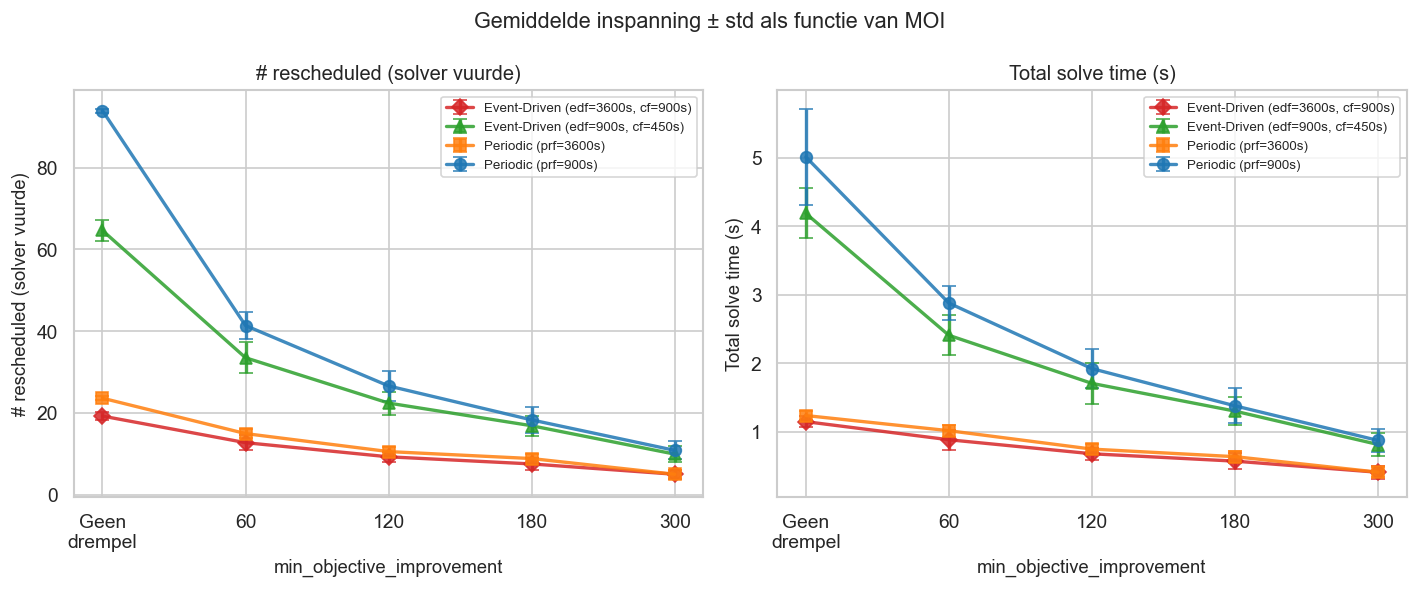

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, label in zip(axes, effort_cols, effort_labels):
    for tkey in trigger_keys:
        sub = df[df["trigger_key"] == tkey]
        grp = sub.groupby("moi")[metric].agg(["mean", "std"]).reindex(MOI_PRESENT)

        ax.errorbar(
            range(len(MOI_PRESENT)),
            grp["mean"],
            yerr=grp["std"],
            label=TRIGGER_LABELS.get(tkey, tkey),
            marker=marker_per_trigger.get(tkey, "o"),
            color=color_per_trigger.get(tkey, "gray"),
            linewidth=2,
            markersize=7,
            capsize=4,
            alpha=0.85,
        )

    ax.set_title(label)
    ax.set_xlabel("min_objective_improvement")
    ax.set_xticks(range(len(MOI_PRESENT)))
    ax.set_xticklabels([MOI_LABELS.get(m, str(m)) for m in MOI_PRESENT])
    ax.set_ylabel(label)
    ax.legend(fontsize=8)

plt.suptitle("Gemiddelde inspanning ± std als functie van MOI", fontsize=13)
plt.tight_layout()
plt.show()

### 4.1 Skip-ratio: hoe vaak hield de MOI-drempel de solver tegen?

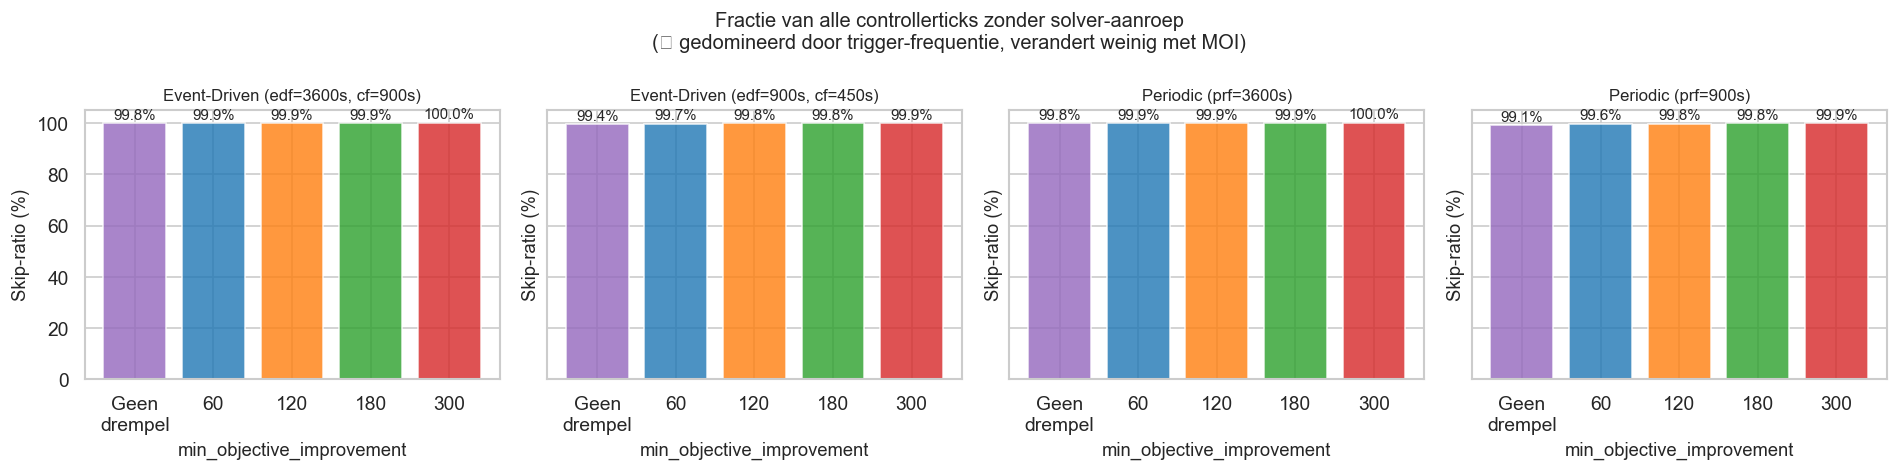

In [11]:
# n_skipped bevat alle controllerticks zonder solver-aanroep (gedomineerd door trigger-freq).
# De meest zinvolle maatstaf is n_rescheduled zelf: hoeveel keer vuurde de solver daadwerkelijk?
# Hier tonen we het skip-percentage als aanvulling.

df["skip_ratio"] = df["n_skipped"] / (df["n_rescheduled"] + df["n_skipped"])

fig, axes = plt.subplots(1, n_triggers, figsize=(4 * n_triggers, 4), sharey=True)
if n_triggers == 1:
    axes = [axes]

for ax, tkey in zip(axes, trigger_keys):
    sub = df[df["trigger_key"] == tkey]
    grp = sub.groupby("moi")["skip_ratio"].mean() * 100

    bars = ax.bar(
        range(len(MOI_PRESENT)),
        [grp.get(m, 0) for m in MOI_PRESENT],
        color=[MOI_COLORS.get(m, "#aaaaaa") for m in MOI_PRESENT],
        alpha=0.8,
        edgecolor="white",
    )

    for bar, m in zip(bars, MOI_PRESENT):
        val = grp.get(m, 0)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}%",
            ha="center", va="bottom", fontsize=9,
        )

    ax.set_xticks(range(len(MOI_PRESENT)))
    ax.set_xticklabels([MOI_LABELS.get(m, str(m)) for m in MOI_PRESENT])
    ax.set_title(TRIGGER_LABELS.get(tkey, tkey), fontsize=10)
    ax.set_xlabel("min_objective_improvement")
    ax.set_ylabel("Skip-ratio (%)")
    ax.set_ylim(0, 105)

plt.suptitle("Fractie van alle controllerticks zonder solver-aanroep\n"
             "(⚠ gedomineerd door trigger-frequentie, verandert weinig met MOI)", fontsize=12)
plt.tight_layout()
plt.show()

### 4.2 Relatieve reductie in n_rescheduled t.o.v. "Geen drempel"

`n_rescheduled` toont hoeveel keer de solver daadwerkelijk gevuurd heeft.  
Referentie = **Geen drempel** (MOI = −10 000) — meest agressief, houdt niets tegen.  
Hogere MOI → minder solver-aanroepen → getal stijgt.

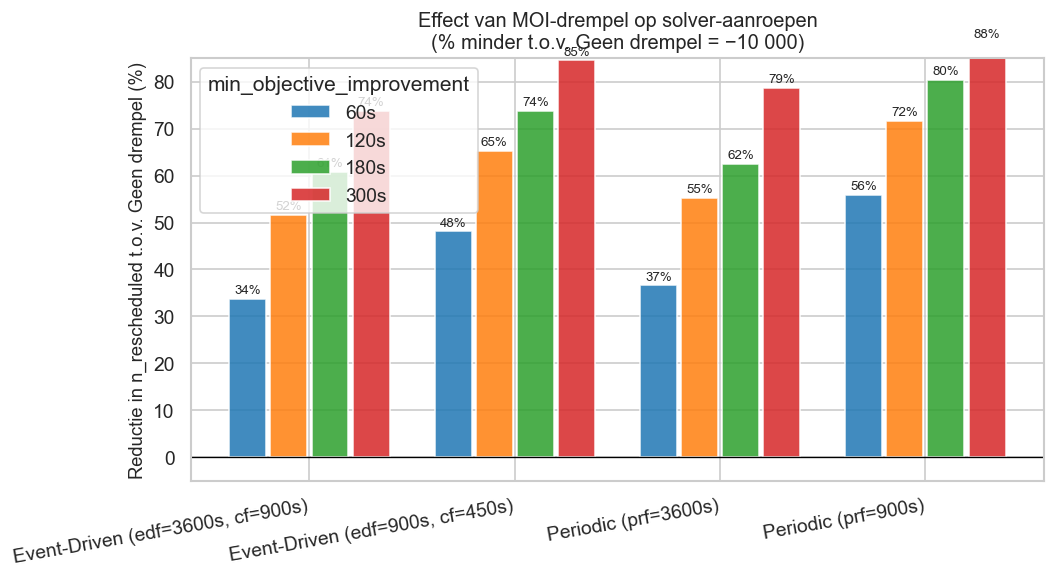

In [12]:
# Alleen MOI-waarden waarvoor we een referentie (geen drempel) hebben
REF_MOI   = -10000
moi_plot  = [m for m in MOI_PRESENT if m != REF_MOI]

fig, ax = plt.subplots(figsize=(9, 5))

width  = 0.2
x_pos  = np.arange(len(trigger_keys))

for i, moi in enumerate(moi_plot):
    reductions = []
    for tkey in trigger_keys:
        sub  = df[df["trigger_key"] == tkey]
        base = sub[sub["moi"] == REF_MOI]["n_rescheduled"].mean()
        val  = sub[sub["moi"] == moi]["n_rescheduled"].mean()
        pct  = (1 - val / base) * 100 if base > 0 else 0
        reductions.append(pct)

    bars = ax.bar(
        x_pos + i * width,
        reductions,
        width=width * 0.9,
        label=MOI_LABELS_SHORT.get(moi, str(moi)),
        color=MOI_COLORS.get(moi, "#aaaaaa"),
        alpha=0.85,
        edgecolor="white",
    )

    for bar, val in zip(bars, reductions):
        if abs(val) > 1:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                f"{val:.0f}%",
                ha="center", va="bottom", fontsize=8,
            )

ax.set_xticks(x_pos + width * (len(moi_plot) - 1) / 2)
ax.set_xticklabels(
    [TRIGGER_LABELS.get(k, k) for k in trigger_keys],
    rotation=10, ha="right",
)
ax.set_ylabel("Reductie in n_rescheduled t.o.v. Geen drempel (%)")
ax.set_title("Effect van MOI-drempel op solver-aanroepen\n"
             "(% minder t.o.v. Geen drempel = −10 000)")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(title="min_objective_improvement")
ax.set_ylim(-5, 85)

plt.tight_layout()
plt.show()

## 5. Pareto-analyse: TED_combined vs. n_rescheduled

Elke punt = gemiddelde van 50 seeds voor één (trigger × MOI) combinatie.  
**Links-onder** = ideaal: weinig vertraging én weinig solver-aanroepen.

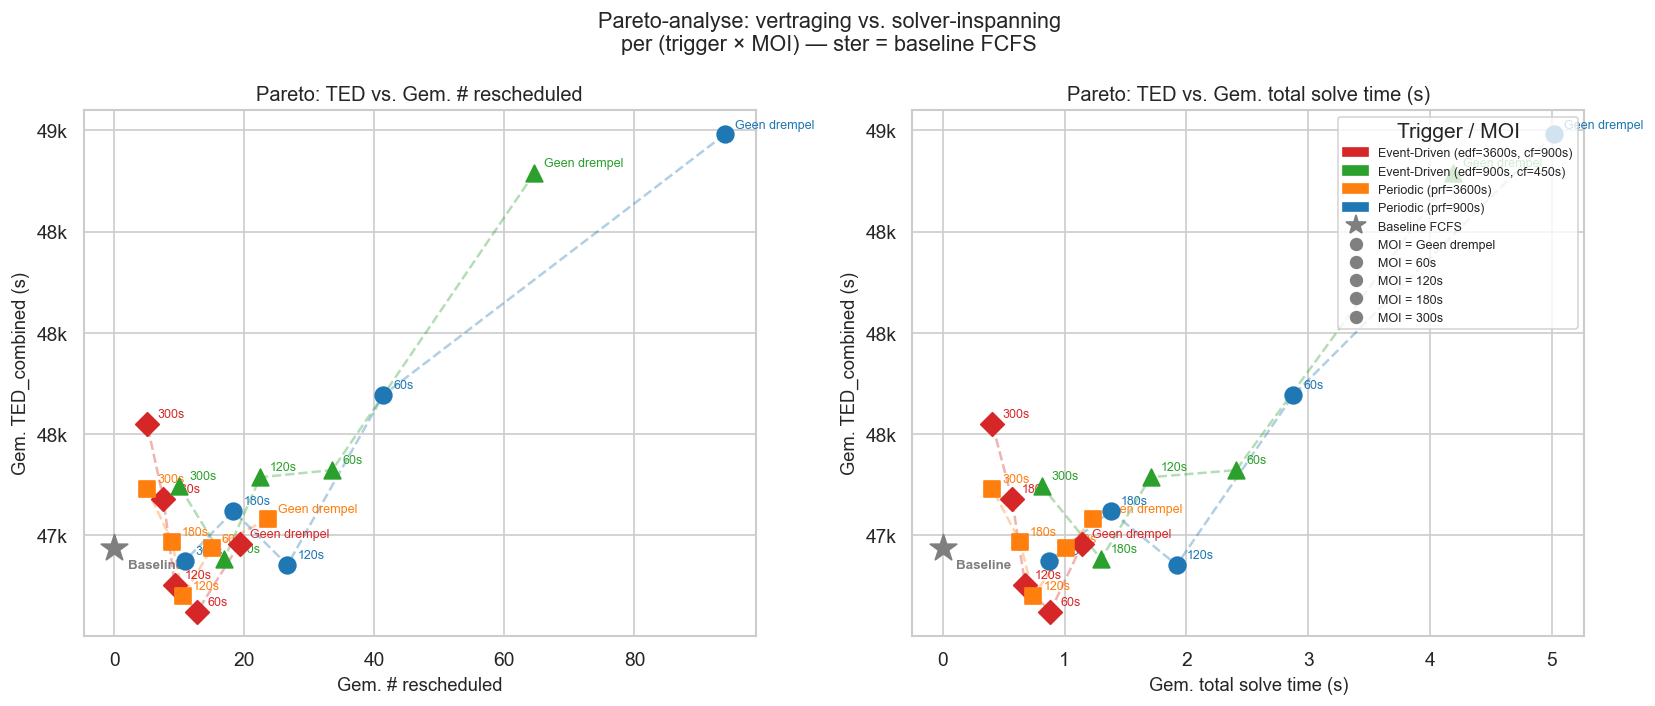

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

pareto_metrics_x = ["n_rescheduled", "total_solve_time"]
pareto_labels_x  = ["Gem. # rescheduled", "Gem. total solve time (s)"]

for ax, x_metric, x_label in zip(axes, pareto_metrics_x, pareto_labels_x):

    # ── Reguliere configs (trigger × MOI) ─────────────────────────────────
    for tkey in trigger_keys:
        sub = df[df["trigger_key"] == tkey]

        for moi in MOI_PRESENT:
            msub  = sub[sub["moi"] == moi]
            if msub.empty:
                continue
            x_val = msub[x_metric].mean()
            y_val = msub["TED_combined"].mean()

            ax.scatter(
                x_val, y_val,
                color=color_per_trigger.get(tkey, "gray"),
                marker=marker_per_trigger.get(tkey, "o"),
                s=100,
                zorder=5,
            )
            ax.annotate(
                MOI_LABELS_SHORT.get(moi, str(moi)),
                (x_val, y_val),
                textcoords="offset points",
                xytext=(6, 4),
                fontsize=7.5,
                color=color_per_trigger.get(tkey, "gray"),
            )

        # Verbind punten per trigger (gesorteerd op MOI)
        grp = sub.groupby("moi")[[x_metric, "TED_combined"]].mean().reindex(MOI_PRESENT)
        grp = grp.dropna()
        ax.plot(
            grp[x_metric], grp["TED_combined"],
            color=color_per_trigger.get(tkey, "gray"),
            alpha=0.35,
            linewidth=1.5,
            linestyle="--",
        )

    # ── Baseline als ster ─────────────────────────────────────────────────
    baseline_x = 0 if x_metric == "n_rescheduled" else df_baseline["total_solve_time"].mean()
    baseline_y = df_baseline["TED_combined"].mean()
    ax.scatter(
        baseline_x, baseline_y,
        color=BASELINE_COLOR,
        marker="*",
        s=280,
        zorder=6,
        label="Baseline FCFS",
    )
    ax.annotate(
        "Baseline",
        (baseline_x, baseline_y),
        textcoords="offset points",
        xytext=(8, -12),
        fontsize=8,
        color=BASELINE_COLOR,
        fontweight="bold",
    )

    ax.set_xlabel(x_label)
    ax.set_ylabel("Gem. TED_combined (s)")
    ax.set_title(f"Pareto: TED vs. {x_label}")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))

# ── Gecombineerde legenda ─────────────────────────────────────────────────
trigger_handles = [
    mpatches.Patch(color=color_per_trigger[k], label=TRIGGER_LABELS.get(k, k))
    for k in trigger_keys
]
baseline_handle = plt.Line2D(
    [0], [0], marker="*", color=BASELINE_COLOR,
    markerfacecolor=BASELINE_COLOR, markersize=12, linestyle="None",
    label="Baseline FCFS",
)
moi_handles = [
    plt.Line2D([0], [0], marker="o", color="gray",
               markerfacecolor="gray", markersize=7, linestyle="None",
               label=f"MOI = {MOI_LABELS_SHORT.get(m, m)}")
    for m in MOI_PRESENT
]

axes[1].legend(
    handles=trigger_handles + [baseline_handle] + moi_handles,
    fontsize=7.5,
    loc="upper right",
    title="Trigger / MOI",
)

plt.suptitle("Pareto-analyse: vertraging vs. solver-inspanning\n"
             "per (trigger × MOI) — ster = baseline FCFS", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Heatmap: relatieve verandering t.o.v. MOI=60

We normaliseren alle metrics ten opzichte van `MOI=60` (= laagste drempel, meest agressief).  
Waarden > 1 = slechter dan MOI=60, waarden < 1 = beter.

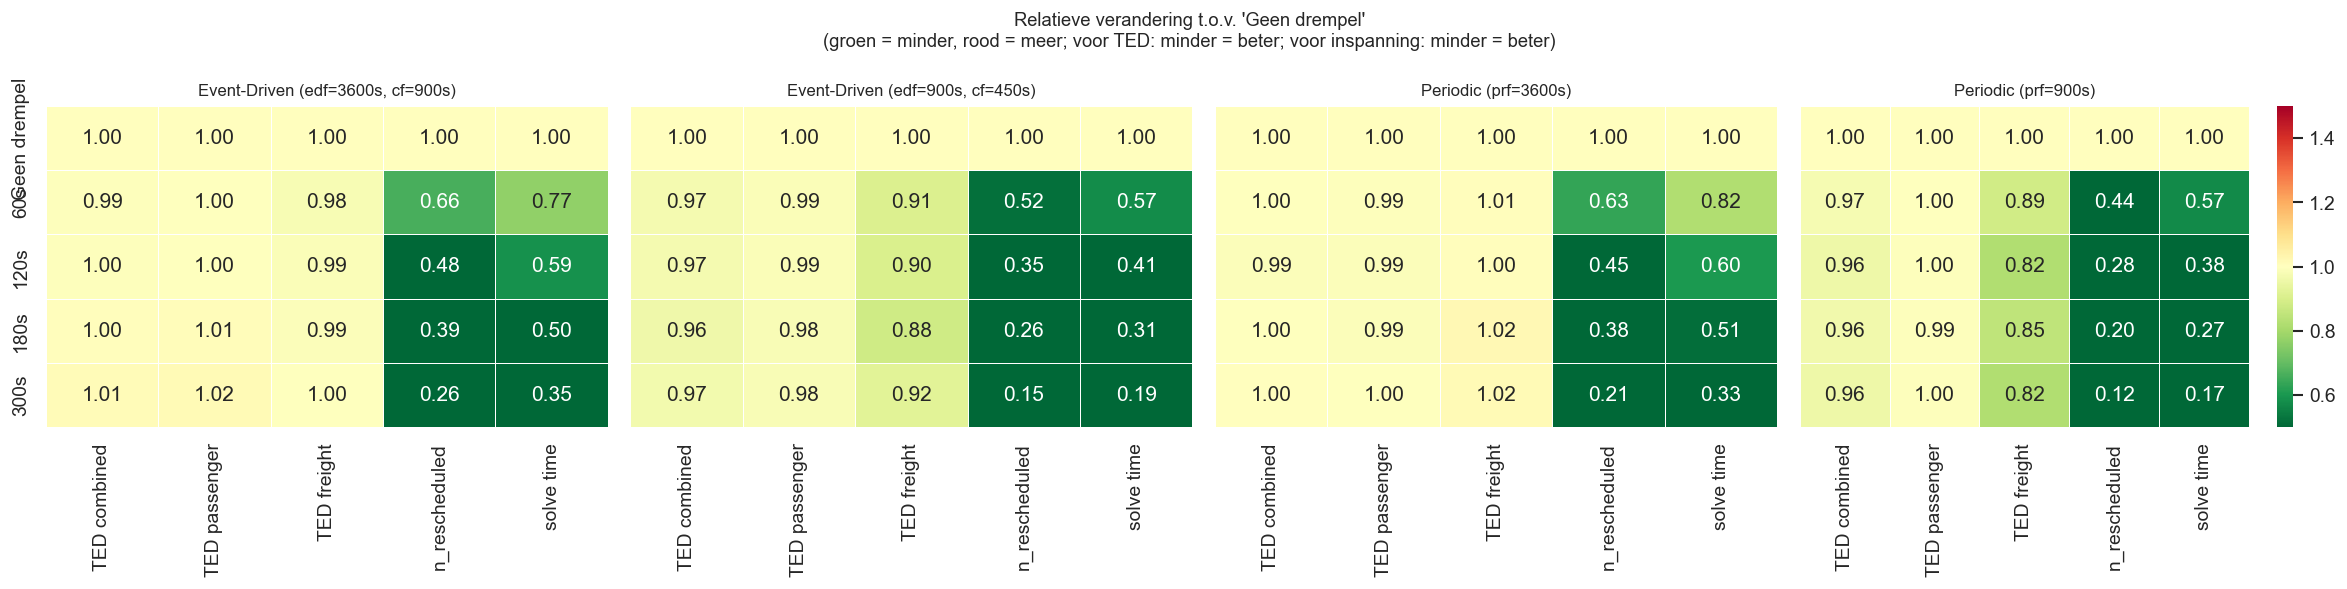

In [14]:
rel_metrics = [
    "TED_combined", "TED_passenger", "TED_freight",
    "n_rescheduled", "total_solve_time",
]
rel_labels = [
    "TED combined", "TED passenger", "TED freight",
    "n_rescheduled", "solve time",
]

# Referentie = "Geen drempel" (MOI = -10000), als die aanwezig is
# Anders val terug op de laagste beschikbare MOI
_ref = -10000 if -10000 in MOI_PRESENT else min(MOI_PRESENT)
ref_label = MOI_LABELS_SHORT.get(_ref, str(_ref))

fig, axes = plt.subplots(1, n_triggers, figsize=(5 * n_triggers, 5), sharey=True)
if n_triggers == 1:
    axes = [axes]

for ax, tkey in zip(axes, trigger_keys):
    sub  = df[df["trigger_key"] == tkey]
    base = sub[sub["moi"] == _ref][rel_metrics].mean()

    matrix = []
    row_labels = []
    for moi in MOI_PRESENT:
        row_vals = sub[sub["moi"] == moi][rel_metrics].mean()
        if row_vals.isna().all():
            continue
        matrix.append((row_vals / base).values)
        row_labels.append(MOI_LABELS_SHORT.get(moi, str(moi)))

    mat_df = pd.DataFrame(matrix, index=row_labels, columns=rel_labels)

    sns.heatmap(
        mat_df,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn_r",
        center=1.0,
        vmin=0.5, vmax=1.5,
        linewidths=0.5,
        cbar=(ax == axes[-1]),
    )
    ax.set_title(TRIGGER_LABELS.get(tkey, tkey), fontsize=10)
    ax.set_xlabel("")

plt.suptitle(
    f"Relatieve verandering t.o.v. '{ref_label}'\n"
    "(groen = minder, rood = meer; voor TED: minder = beter; voor inspanning: minder = beter)",
    fontsize=11,
)
plt.tight_layout()
plt.show()

## 7. Statistische tests

**Kruskal-Wallis test** per trigger-configuratie: zijn er significante verschillen in TED_combined over de 4 MOI-waarden?  
Gevolgd door **pairwise Mann-Whitney U tests** (met Bonferroni-correctie) voor significante gevallen.

In [15]:
ALPHA         = 0.05
N_COMPARISONS = len(list(combinations(MOI_PRESENT, 2)))

print("=" * 70)
print("Kruskal-Wallis test: TED_combined over alle MOI-waarden")
print(f"Bonferroni-correctie: α/{N_COMPARISONS} = {ALPHA/N_COMPARISONS:.4f}")
print("=" * 70)

kruskal_results = {}

for tkey in trigger_keys:
    sub    = df[df["trigger_key"] == tkey]
    groups = [sub[sub["moi"] == m]["TED_combined"].dropna().values for m in MOI_PRESENT]
    groups = [g for g in groups if len(g) >= 3]   # min 3 observaties voor test

    if len(groups) < 2:
        print(f"\n{TRIGGER_LABELS.get(tkey, tkey)}: ⚠ te weinig data")
        continue

    try:
        stat, p_val = kruskal(*groups)
        kruskal_results[tkey] = {"stat": stat, "p": p_val}
        print(f"\n{TRIGGER_LABELS.get(tkey, tkey)}:")
        print(f"  H = {stat:.3f}, p = {p_val:.4f} "
              f"{'*** SIGNIFICANT' if p_val < ALPHA else '(niet sig.)'}")

        if p_val < ALPHA:
            print(f"  → Pairwise Mann-Whitney U "
                  f"(Bonferroni α = {ALPHA/N_COMPARISONS:.4f}):")
            for (m1, m2) in combinations(MOI_PRESENT, 2):
                g1 = sub[sub["moi"] == m1]["TED_combined"].dropna().values
                g2 = sub[sub["moi"] == m2]["TED_combined"].dropna().values
                if len(g1) < 3 or len(g2) < 3:
                    continue
                u_stat, p_mw = mannwhitneyu(g1, g2, alternative="two-sided")
                l1 = MOI_LABELS_SHORT.get(m1, str(m1))
                l2 = MOI_LABELS_SHORT.get(m2, str(m2))
                sig = " *" if p_mw < ALPHA / N_COMPARISONS else ""
                print(f"     {l1:12s} vs {l2:12s}: "
                      f"U={u_stat:.0f}, p={p_mw:.4f}{sig}")
    except Exception as e:
        print(f"  !! Fout: {e}")

Kruskal-Wallis test: TED_combined over alle MOI-waarden
Bonferroni-correctie: α/10 = 0.0050

Event-Driven (edf=3600s, cf=900s):
  H = 3.411, p = 0.4915 (niet sig.)

Event-Driven (edf=900s, cf=450s):
  H = 4.458, p = 0.3476 (niet sig.)

Periodic (prf=3600s):
  H = 0.480, p = 0.9754 (niet sig.)

Periodic (prf=900s):
  H = 7.039, p = 0.1338 (niet sig.)


In [16]:
print("=" * 70)
print("Kruskal-Wallis: n_rescheduled over alle MOI-waarden")
print("=" * 70)

for tkey in trigger_keys:
    sub    = df[df["trigger_key"] == tkey]
    groups = [sub[sub["moi"] == m]["n_rescheduled"].dropna().values for m in MOI_PRESENT]
    groups = [g for g in groups if len(g) >= 3]

    if len(groups) < 2:
        print(f"\n{TRIGGER_LABELS.get(tkey, tkey)}: ⚠ te weinig data")
        continue

    try:
        stat, p_val = kruskal(*groups)
        print(f"\n{TRIGGER_LABELS.get(tkey, tkey)}:")
        print(f"  H = {stat:.3f}, p = {p_val:.4f} "
              f"{'*** SIGNIFICANT' if p_val < ALPHA else '(niet sig.)'}")

        if p_val < ALPHA:
            print(f"  → Pairwise Mann-Whitney U "
                  f"(Bonferroni α = {ALPHA/N_COMPARISONS:.4f}):")
            for (m1, m2) in combinations(MOI_PRESENT, 2):
                g1 = sub[sub["moi"] == m1]["n_rescheduled"].dropna().values
                g2 = sub[sub["moi"] == m2]["n_rescheduled"].dropna().values
                if len(g1) < 3 or len(g2) < 3:
                    continue
                u_stat, p_mw = mannwhitneyu(g1, g2, alternative="two-sided")
                l1 = MOI_LABELS_SHORT.get(m1, str(m1))
                l2 = MOI_LABELS_SHORT.get(m2, str(m2))
                sig = " *" if p_mw < ALPHA / N_COMPARISONS else ""
                print(f"     {l1:12s} vs {l2:12s}: "
                      f"U={u_stat:.0f}, p={p_mw:.4f}{sig}")
    except Exception as e:
        print(f"  !! Fout: {e}")

Kruskal-Wallis: n_rescheduled over alle MOI-waarden

Event-Driven (edf=3600s, cf=900s):
  H = 223.773, p = 0.0000 *** SIGNIFICANT
  → Pairwise Mann-Whitney U (Bonferroni α = 0.0050):
     Geen drempel vs 60s         : U=2500, p=0.0000 *
     Geen drempel vs 120s        : U=2500, p=0.0000 *
     Geen drempel vs 180s        : U=2500, p=0.0000 *
     Geen drempel vs 300s        : U=2500, p=0.0000 *
     60s          vs 120s        : U=2310, p=0.0000 *
     60s          vs 180s        : U=2466, p=0.0000 *
     60s          vs 300s        : U=2500, p=0.0000 *
     120s         vs 180s        : U=2078, p=0.0000 *
     120s         vs 300s        : U=2490, p=0.0000 *
     180s         vs 300s        : U=2290, p=0.0000 *

Event-Driven (edf=900s, cf=450s):
  H = 230.402, p = 0.0000 *** SIGNIFICANT
  → Pairwise Mann-Whitney U (Bonferroni α = 0.0050):
     Geen drempel vs 60s         : U=2400, p=0.0000 *
     Geen drempel vs 120s        : U=2304, p=0.0000 *
     Geen drempel vs 180s        : U=23

## 8. Delay Ratio: effect MOI op goederenverhouding

`delay_ratio = (TED_freight / n_freight) / (TED_passenger / n_passenger)`  
DR > 1 → goederentreinen dragen proportioneel meer vertraging dan passagierstreinen.

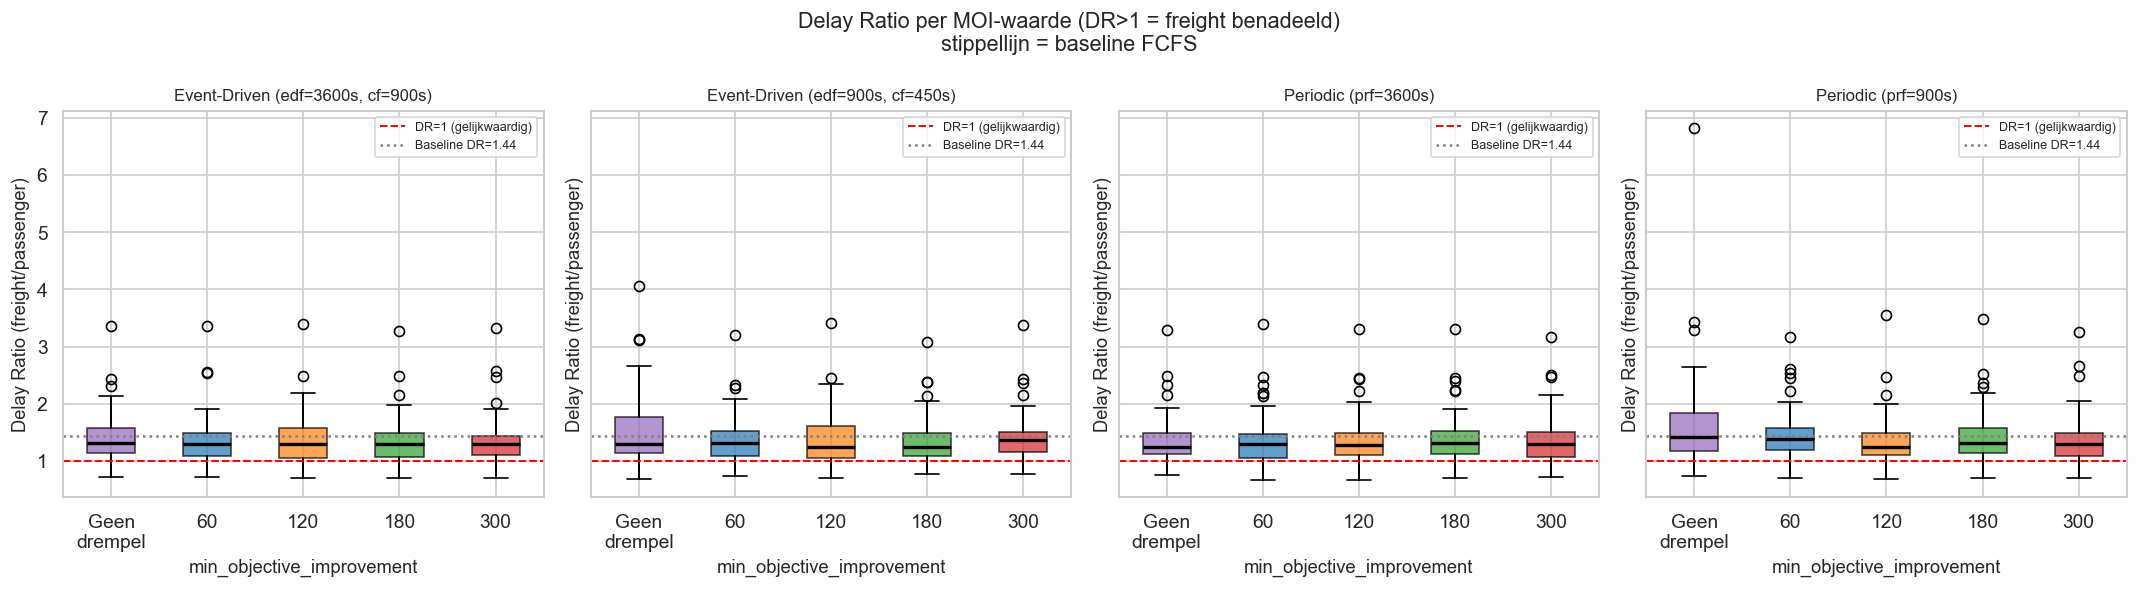

In [17]:
fig, axes = plt.subplots(1, n_triggers, figsize=(4.5 * n_triggers, 5), sharey=True)
if n_triggers == 1:
    axes = [axes]

for ax, tkey in zip(axes, trigger_keys):
    sub = df[df["trigger_key"] == tkey]

    data_per_moi = [sub[sub["moi"] == m]["delay_ratio"].dropna().values for m in MOI_PRESENT]

    bp = ax.boxplot(
        data_per_moi,
        labels=[MOI_LABELS.get(m, str(m)) for m in MOI_PRESENT],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
    )

    for patch, m in zip(bp["boxes"], MOI_PRESENT):
        patch.set_facecolor(MOI_COLORS.get(m, "#aaaaaa"))
        patch.set_alpha(0.7)

    ax.axhline(1.0, color="red", linestyle="--", linewidth=1.2, label="DR=1 (gelijkwaardig)")

    # Baseline delay ratio
    bl_dr = df_baseline["delay_ratio"].mean()
    ax.axhline(bl_dr, color=BASELINE_COLOR, linestyle=":", linewidth=1.5,
               label=f"Baseline DR={bl_dr:.2f}")

    ax.set_title(TRIGGER_LABELS.get(tkey, tkey), fontsize=10)
    ax.set_xlabel("min_objective_improvement")
    ax.set_ylabel("Delay Ratio (freight/passenger)")
    ax.legend(fontsize=7.5)

plt.suptitle("Delay Ratio per MOI-waarde (DR>1 = freight benadeeld)\n"
             "stippellijn = baseline FCFS", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Overzichtstabel

Gemiddelden per trigger × MOI voor alle kernmetrics.

In [18]:
summary_metrics = [
    "TED_combined", "TED_passenger", "TED_freight",
    "delay_ratio",
    "n_rescheduled", "total_solve_time",
]

records = []

# ── Baseline rij ─────────────────────────────────────────────────────────
bl_dl = deadlock_summary[deadlock_summary["trigger_key"] == "baseline"]
bl_n_dl  = int(bl_dl["n_deadlock"].sum()) if not bl_dl.empty else 0
bl_n_tot = int(bl_dl["n_total"].sum())    if not bl_dl.empty else len(df_baseline)
bl_row   = {
    "Trigger":      "Baseline (FCFS)",
    "MOI":          "—",
    "n_runs":       bl_n_tot,
    "n_deadlocks":  bl_n_dl,
    "deadlock_%":   round(bl_n_dl / bl_n_tot * 100, 1) if bl_n_tot > 0 else 0.0,
}
for m in summary_metrics:
    if m in df_baseline.columns:
        bl_row[m] = df_baseline[m].mean()
records.append(bl_row)

# ── Trigger × MOI rijen ──────────────────────────────────────────────────
for tkey in trigger_keys:
    sub = df[df["trigger_key"] == tkey]
    for moi in MOI_PRESENT:
        msub = sub[sub["moi"] == moi]

        dl_row = deadlock_summary[
            (deadlock_summary["trigger_key"] == tkey) &
            (deadlock_summary["moi"] == moi)
        ]
        n_dl  = int(dl_row["n_deadlock"].iloc[0]) if not dl_row.empty else 0
        n_tot = int(dl_row["n_total"].iloc[0])    if not dl_row.empty else len(msub)

        row = {
            "Trigger":     TRIGGER_LABELS.get(tkey, tkey),
            "MOI":         MOI_LABELS_SHORT.get(moi, str(moi)),
            "n_runs":      n_tot,
            "n_deadlocks": n_dl,
            "deadlock_%":  round(n_dl / n_tot * 100, 1) if n_tot > 0 else 0.0,
        }
        for m in summary_metrics:
            if m in msub.columns:
                row[m] = msub[m].mean()
        records.append(row)

summary_df = pd.DataFrame(records)

format_dict = {
    "TED_combined":     "{:.0f}",
    "TED_passenger":    "{:.0f}",
    "TED_freight":      "{:.0f}",
    "delay_ratio":      "{:.3f}",
    "n_rescheduled":    "{:.1f}",
    "total_solve_time": "{:.1f}",
    "deadlock_%":       "{:.1f}%",
}

styled = summary_df.style
for col, fmt in format_dict.items():
    if col in summary_df.columns:
        styled = styled.format({col: fmt}, na_rep="—")

styled = (
    styled
    .background_gradient(subset=["TED_combined"], cmap="RdYlGn_r", axis=0)
    .background_gradient(subset=["deadlock_%"],   cmap="Reds",      axis=0, vmin=0, vmax=10)
)

display(styled)

,Trigger,MOI,n_runs,n_deadlocks,deadlock_%,TED_combined,TED_passenger,TED_freight,delay_ratio,n_rescheduled,total_solve_time
0,Baseline (FCFS),—,50,1,2.0%,46934.702041,37455.279592,9479.422449,1.435135,0.000000,0.000000
1,"Event-Driven (edf=3600s, cf=900s)",Geen drempel,50,0,0.0%,46955.810000,37651.458000,9304.352000,1.400215,19.260000,1.145312
2,"Event-Driven (edf=3600s, cf=900s)",60s,50,0,0.0%,46620.962000,37515.832000,9105.130000,1.375183,12.760000,0.880571
3,"Event-Driven (edf=3600s, cf=900s)",120s,50,0,0.0%,46753.012000,37578.106000,9174.906000,1.384487,9.300000,0.675505
4,"Event-Driven (edf=3600s, cf=900s)",180s,50,0,0.0%,47177.088000,37962.386000,9214.702000,1.374963,7.560000,0.567607
5,"Event-Driven (edf=3600s, cf=900s)",300s,50,0,0.0%,47549.374000,38276.794000,9272.580000,1.372359,5.040000,0.404771
6,"Event-Driven (edf=900s, cf=450s)",Geen drempel,50,2,4.0%,48789.775000,38467.172917,10322.602083,1.524071,64.625000,4.191303
7,"Event-Driven (edf=900s, cf=450s)",60s,50,0,0.0%,47320.666000,37931.958000,9388.708000,1.401151,33.520000,2.408413
8,"Event-Driven (edf=900s, cf=450s)",120s,50,2,4.0%,47285.537500,37960.827083,9324.710417,1.395837,22.437500,1.705201
9,"Event-Driven (edf=900s, cf=450s)",180s,50,1,2.0%,46880.885714,37785.728571,9095.157143,1.357274,16.897959,1.299397


## 10. Per trigger: diepteanalyse MOI-effect

Voor elke trigger-configuratie afzonderlijk: vergelijking van alle seed-distributies.

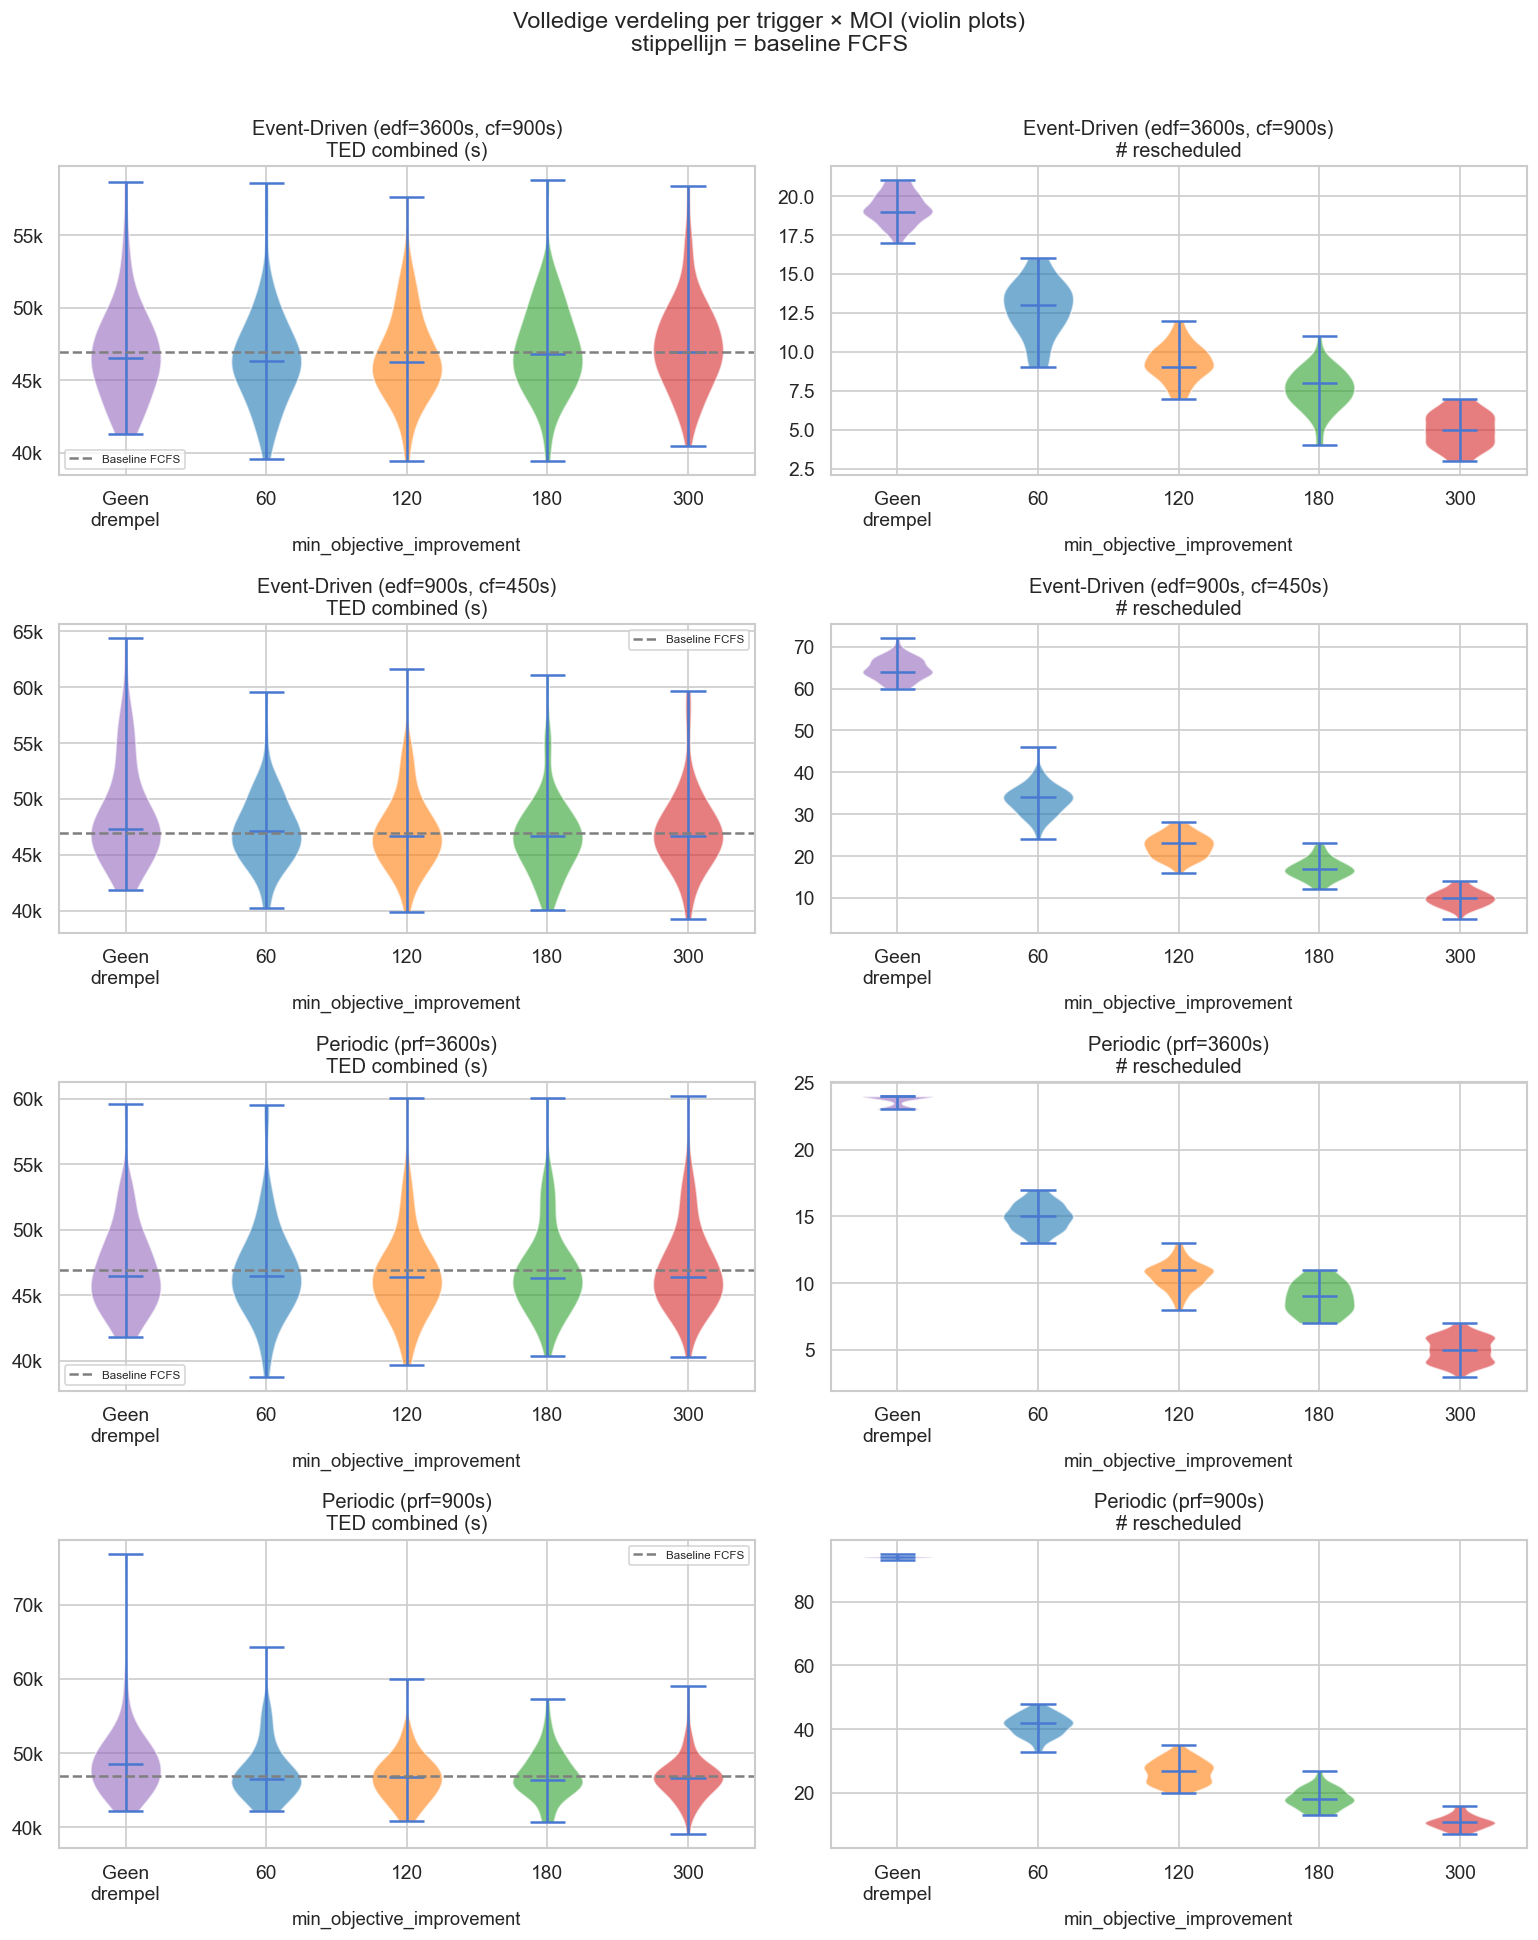

In [19]:
fig, axes = plt.subplots(n_triggers, 2, figsize=(13, 4 * n_triggers))
if n_triggers == 1:
    axes = axes.reshape(1, -1)

x_tick_labels = [MOI_LABELS.get(m, str(m)) for m in MOI_PRESENT]

for row_i, tkey in enumerate(trigger_keys):
    sub = df[df["trigger_key"] == tkey]

    # ── Violin: TED_combined ───────────────────────────────────────────────
    ax = axes[row_i][0]
    data_ted = [sub[sub["moi"] == m]["TED_combined"].dropna().values for m in MOI_PRESENT]
    # Verwijder lege groepen voor violinplot
    nonempty = [(i, d) for i, d in enumerate(data_ted) if len(d) > 1]
    if nonempty:
        positions, data_plot = zip(*nonempty)
        parts = ax.violinplot(data_plot, positions=positions, showmedians=True, showextrema=True)
        for body, pos in zip(parts["bodies"], positions):
            body.set_facecolor(MOI_COLORS.get(MOI_PRESENT[pos], "#aaaaaa"))
            body.set_alpha(0.6)

    ax.axhline(baseline_means["TED_combined"], color=BASELINE_COLOR, linestyle="--",
               linewidth=1.5, label="Baseline FCFS")
    ax.legend(fontsize=7)
    ax.set_xticks(range(len(MOI_PRESENT)))
    ax.set_xticklabels(x_tick_labels)
    ax.set_title(f"{TRIGGER_LABELS.get(tkey, tkey)}\nTED combined (s)")
    ax.set_xlabel("min_objective_improvement")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))

    # ── Violin: n_rescheduled ─────────────────────────────────────────────
    ax = axes[row_i][1]
    data_nres = [sub[sub["moi"] == m]["n_rescheduled"].dropna().values for m in MOI_PRESENT]
    nonempty2 = [(i, d) for i, d in enumerate(data_nres) if len(d) > 1]
    if nonempty2:
        positions2, data_plot2 = zip(*nonempty2)
        parts2 = ax.violinplot(data_plot2, positions=positions2, showmedians=True, showextrema=True)
        for body, pos in zip(parts2["bodies"], positions2):
            body.set_facecolor(MOI_COLORS.get(MOI_PRESENT[pos], "#aaaaaa"))
            body.set_alpha(0.6)

    ax.set_xticks(range(len(MOI_PRESENT)))
    ax.set_xticklabels(x_tick_labels)
    ax.set_title(f"{TRIGGER_LABELS.get(tkey, tkey)}\n# rescheduled")
    ax.set_xlabel("min_objective_improvement")

plt.suptitle("Volledige verdeling per trigger × MOI (violin plots)\n"
             "stippellijn = baseline FCFS", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 11. Conclusies

*(Vul aan op basis van de plots hierboven)*

### Deadlocks (§2.1)
- Totaal: ... deadlocks op ... runs (...%)
- Hoogste rate: ... bij trigger ... / MOI ...
- Patroon: deadlocks lijken (wel / niet) samen te hangen met MOI-waarde
- `periodic_prf900` lijkt (meer / minder) gevoelig dan event-driven configs: ...

### Referentie: Baseline FCFS
- Gem. TED_combined baseline: ... s (n_deadlocks = ...)
- n_rescheduled = 0 (solver vuurt nooit)

### Effect op vertraging (TED_combined) per trigger
- **Geen drempel** vs. drempel (60–300 s): ...
- **Periodic (prf=900)**: ...
- **Periodic (prf=3600)**: ...
- **Event-Driven (edf=900)**: ...
- **Event-Driven (edf=3600)**: ...

### Effect op solver-inspanning (n_rescheduled)
- Hogere MOI → duidelijk minder solver-aanroepen: ...
- "Geen drempel" vs. MOI=300: % reductie ≈ ...

### Pareto-trade-off
- Beste verhouding TED/inspanning: MOI = ... voor trigger ...
- Verbetering t.o.v. baseline: ... %

### Statistische significantie
- TED_combined over MOI-waarden: ...
- n_rescheduled over MOI-waarden: altijd significant (verwacht)